In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [134]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [135]:
def load_data(filepath):
    df = pd.read_csv(filepath)
    return df   

In [136]:
df = load_data("../Data/Salary_Data.csv")

In [ ]:
## This code imports the required libraries for data analysis, visualization, preprocessing, and linear regression modeling. 
# A function load_data() is defined to read the dataset from a CSV file using Pandas. 
# The salary dataset is then loaded into a DataFrame, and df.head() is used to display the first few records for initial data inspection and understanding.

In [137]:
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [138]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 612.0 bytes


In [139]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [140]:
feature = df[['YearsExperience']]
target = df[['Salary']]

In [141]:
feature.head()

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2


In [142]:
x_tr, x_te, y_tr, y_te = train_test_split(feature, target, test_size=0.5, random_state=42)

In [143]:
x_tr.shape, x_te.shape, y_tr.shape, y_te.shape

((15, 1), (15, 1), (15, 1), (15, 1))

In [144]:
scalar = StandardScaler()
x_tr_scaled = scalar.fit_transform(x_tr)
x_te_scaled = scalar.fit_transform(x_te)

In [145]:
linear_model = LinearRegression()
linear_model.fit(x_tr_scaled, y_tr)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [146]:
y_pred = linear_model.predict(x_te_scaled)

In [147]:
linear_model.coef_

array([[26413.3539151]])

In [ ]:
#This code visualizes the performance of the linear regression model by comparing the actual and predicted salary values. 
# A scatter plot is used to display the actual data points, while a line plot represents the predicted salaries. 
# The red dashed vertical lines show the difference (error) between actual and predicted values, helping to evaluate the model's prediction accuracy.

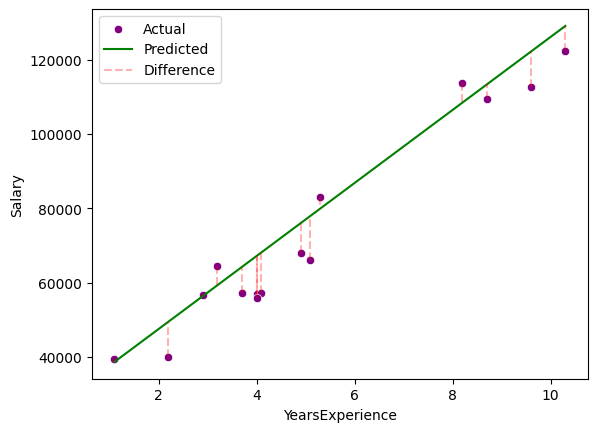

In [148]:
order = np.argsort(x_te['YearsExperience'].values)
sns.scatterplot(x=x_te['YearsExperience'].values, y=y_te['Salary'].values, label='Actual', color='purple')
sns.lineplot(x=x_te['YearsExperience'].values[order], y=y_pred.ravel()[order], label='Predicted', color='g')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.vlines(
    x=x_te['YearsExperience'].values[order],
    ymin=y_te['Salary'].values[order],
    ymax=y_pred.ravel()[order],
    colors='r',
    linestyles='--',
    label='Difference',
    alpha=0.3
)
plt.legend()
plt.show()
plt.show()

In [149]:
MSE = mean_squared_error(y_true=y_te, y_pred=y_pred)
print(f"Mean Square Error: {MSE}")

Mean Square Error: 61463554.90419144
